# TF-IDF Clustering Analysis
This notebook performs TF-IDF vectorization and K-Means clustering on text data

## 1. Install Required Packages
Run this cell first to install necessary packages

In [1]:
# !pip install umap-learn
# !pip install scipy

## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from gensim.models.phrases import Phraser
from tqdm import tqdm
import os
from scipy.special import softmax

## 3. Text Preprocessing Function

In [3]:
def preprocess(text, stop_words, lemmatizer, bigram_phraser):
    if not isinstance(text, str) or not text.strip():
        return []
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens 
              if word not in stop_words and len(word) > 2]
    tokens = bigram_phraser[tokens]
    return tokens

## 4. Visualization Function

In [4]:
def plot_tfidf_embeddings(tfidf_matrix, labels, plot_dir, iteration="final"):
    print("Starting TF-IDF embedding visualization...")
    try:
        reducer = umap.UMAP(random_state=42, n_neighbors=30, min_dist=0.05, metric='cosine')
        proj = reducer.fit_transform(tfidf_matrix)
        plt.figure(figsize=(10, 8))
        scatter = plt.scatter(proj[:, 0], proj[:, 1], c=labels, cmap='Spectral', s=10, alpha=0.6)
        plt.colorbar(scatter, label='Cluster Labels')
        plt.title(f'TF-IDF + K-Means Embedding Space (Iteration {iteration})')
        plot_path = os.path.join(plot_dir, f'tfidf_kmeans_scatter_iter_{iteration}.png')
        os.makedirs(plot_dir, exist_ok=True)
        plt.savefig(plot_path, bbox_inches='tight', dpi=300)
        plt.show()  # Display plot in notebook
        plt.close()
        print(f"TF-IDF + K-Means scatter plot saved to {plot_path}")
    except Exception as e:
        print(f"Error: Failed to generate TF-IDF scatter plot: {str(e)}")
        raise

## 5. Confidence Score Computation Function

In [5]:
def compute_confidence_scores(tfidf_matrix, kmeans_model):
    """
    Compute confidence scores for each sample's cluster assignment based on distances to centroids.
    
    Args:
        tfidf_matrix: Sparse TF-IDF matrix of shape (n_samples, n_features)
        kmeans_model: Fitted KMeans model with cluster centers
    
    Returns:
        confidence_scores: Array of confidence scores for assigned clusters
    """
    print("Computing confidence scores for cluster assignments...")
    try:
        # Get distances to all centroids
        distances = kmeans_model.transform(tfidf_matrix)  # Shape: (n_samples, n_clusters)
        # Apply softmax over negative distances to get probabilities
        confidence_scores = softmax(-distances, axis=1)
        # Extract confidence for the assigned cluster
        assigned_clusters = kmeans_model.labels_
        confidence = np.array([confidence_scores[i, assigned_clusters[i]] 
                              for i in range(len(assigned_clusters))])
        print("Confidence scores computed successfully")
        return confidence
    except Exception as e:
        print(f"Failed to compute confidence scores: {str(e)}")
        raise

## 6. Download NLTK Data

In [6]:
# Download required NLTK data
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

print("NLTK data downloaded successfully!")

NLTK data downloaded successfully!


## 7. Initialize NLP Tools and Stopwords

In [7]:
# Initialize NLP tools for preprocessing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Add custom stopwords
custom_stopwords = {
    'allow', 'class', 'available', 'part', 'case', 'lead', 'shall', 'product', 'operate',
    'operational', 'result', 'input', 'dependent', 'preference', 'item', 'without', 'let',
    'returned', 'message', 'every', 'system', 'run', 'fully', 'major', 'reasonable',
    'software', 'user', 'able', 'ability', 'support', 'year', 'expected', 'must',
    'information', 'data', 'use', 'using', 'provide', 'successfully', 'one', 'waiter',
    'include', 'accommodate', 'event', 'technique', 'recent', 'administrator', 'search',
    'add', 'allows', 'achieve', 'way', 'outside', 'release', 'launch', 'allowed', 'entered',
    'within', 'first', 'new', 'izogn', 'wcs', 'course', 'time', 'help', 'learn', 'ccr', 'cma',
    'review', 'star', 'rating', 'good', 'great', 'course', 'learn', 'learning',
    'would', 'like', 'could', 'one', 'bit', 'week', 'think', 'much', 'really',
    'lot', 'new', 'thank', 'thanks', 'many', 'well', 'also', 'get', 'time',
    'truly', 'even', 'make', 'see', 'content', 'material', 'class', 'work',
    'way', 'understand', 'information', 'helpful', 'useful', 'knowledge',
    'day', 'help', 'easy'
}
stop_words.update(custom_stopwords)

print(f"Total stopwords: {len(stop_words)}")

Total stopwords: 300


## 8. Load Seed Words and Bigram Phraser

In [8]:
try:
    seed_words = pd.read_csv('../../datasets/seed_words.csv').groupby('Category')['SeedWord'].apply(list).to_dict()
    seed_word_set = set(word for words in seed_words.values() for word in words)
    stop_words = stop_words - seed_word_set
    print("Seed words loaded successfully")
except Exception as e:
    print(f"Error loading seed words: {str(e)}")
    raise

try:
    bigram_phraser = Phraser.load('../../train/Model_LDA/models/bigram_phraser')
    print("Bigram phraser loaded successfully")
except Exception as e:
    print(f"Error loading bigram phraser: {str(e)}")
    raise

Seed words loaded successfully
Bigram phraser loaded successfully


## 9. Load Training Data

In [9]:
train_data_path = '../../datasets/selected_pseudo_labeled.csv'
try:
    train_df = pd.read_csv(train_data_path)
    if 'text' not in train_df.columns:
        raise ValueError("Training CSV must contain 'text' column")
    train_df['text'] = train_df['text'].fillna("")
    print(f"Training data loaded: {len(train_df)} reviews")
    print(f"Training data columns: {train_df.columns.tolist()}")
    print(f"Training data shape: {train_df.shape}")
except Exception as e:
    print(f"Error loading training data: {str(e)}")
    raise

Training data loaded: 93115 reviews
Training data columns: ['original_index', 'topic', 'confidence', 'text', 'topic_probs']
Training data shape: (93115, 5)


## 10. Preprocess Training Data

In [10]:
print("Preprocessing training data...")

# Enable tqdm for pandas
tqdm.pandas()

train_df['processed_tokens'] = train_df['text'].progress_apply(
    lambda x: preprocess(x, stop_words, lemmatizer, bigram_phraser)
)

# Filter out empty processed tokens
valid_indices = [i for i, tokens in enumerate(train_df['processed_tokens']) if tokens]
train_df = train_df.iloc[valid_indices].copy()
train_df['processed_text'] = train_df['processed_tokens'].apply(lambda x: ' '.join(x))

print(f"Valid training reviews after preprocessing: {len(train_df)}")

Preprocessing training data...


100%|██████████| 93115/93115 [00:04<00:00, 20628.79it/s]


Valid training reviews after preprocessing: 93115


## 11. Fit TF-IDF Vectorizer on Training Data

In [11]:
print("Fitting TF-IDF vectorizer...")

tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # Adjust parameters as needed
tfidf_vectorizer.fit(train_df['processed_text'].values)

try:
    with open('../../train/tfidf_vectorizer.pkl', 'wb') as f:
        pickle.dump(tfidf_vectorizer, f)
    print("TF-IDF vectorizer saved successfully")
except Exception as e:
    print(f"Error saving TF-IDF vectorizer: {str(e)}")
    raise

Fitting TF-IDF vectorizer...
TF-IDF vectorizer saved successfully


## 12. Load Test Data

In [12]:
test_data_path = '../../datasets/review_test.csv'
output_dir = '../../datasets'
plot_dir = 'embeddings_plots'

try:
    test_df = pd.read_csv(test_data_path)
    if 'processed_reviews' not in test_df.columns:
        raise ValueError("Test CSV must contain 'processed_reviews' column")
    test_df['processed_reviews'] = test_df['processed_reviews'].fillna("")
    print(f"Test data loaded: {len(test_df)} reviews")
    print(f"Test data columns: {test_df.columns.tolist()}")
    print(f"Test data shape: {test_df.shape}")
except Exception as e:
    print(f"Error loading test data: {str(e)}")
    raise

Test data loaded: 71630 reviews
Test data columns: ['processed_reviews']
Test data shape: (71630, 1)


## 13. Preprocess Test Data

In [13]:
print("Preprocessing test data...")

test_df['processed_tokens'] = test_df['processed_reviews'].progress_apply(
    lambda x: preprocess(x, stop_words, lemmatizer, bigram_phraser)
)

# Filter out empty processed tokens
valid_indices = [i for i, tokens in enumerate(test_df['processed_tokens']) if tokens]
test_df = test_df.iloc[valid_indices].copy()
test_df['processed_text'] = test_df['processed_tokens'].apply(lambda x: ' '.join(x))

print(f"Valid test reviews after preprocessing: {len(test_df)}")

Preprocessing test data...


100%|██████████| 71630/71630 [00:02<00:00, 24339.92it/s]

Valid test reviews after preprocessing: 70412


## 14. Transform Test Data with TF-IDF

In [14]:
# Transform test data with TfidfVectorizer
tfidf_matrix = tfidf_vectorizer.transform(test_df['processed_text'].values)
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")

TF-IDF matrix shape: (70412, 5000)


## 15. Perform K-Means Clustering

In [15]:
print("Running K-Means clustering...")

kmeans = KMeans(n_clusters=7, random_state=42)
cluster_labels = kmeans.fit_predict(tfidf_matrix)
test_df['cluster_label'] = cluster_labels

print(f"Clustering complete. Found {len(np.unique(cluster_labels))} clusters")
print(f"Cluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Running K-Means clustering...
Clustering complete. Found 7 clusters
Cluster distribution:
0     2615
1     2306
2    56228
3     1337
4     2709
5     2383
6     2834
Name: count, dtype: int64


## 16. Compute Confidence Scores

In [16]:
try:
    confidence_scores = compute_confidence_scores(tfidf_matrix, kmeans)
    test_df['confidence_score'] = confidence_scores
    print("Confidence scores computed successfully")
    print(f"Average confidence score: {np.mean(confidence_scores):.4f}")
    print(f"Confidence score range: {np.min(confidence_scores):.4f} - {np.max(confidence_scores):.4f}")
except Exception as e:
    print(f"Error computing confidence scores: {str(e)}")
    raise

Computing confidence scores for cluster assignments...
Confidence scores computed successfully
Confidence scores computed successfully
Average confidence score: 0.1528
Confidence score range: 0.1464 - 0.2109


## 17. Evaluate Clustering Performance

In [17]:
print("Computing Silhouette Score...")

if len(np.unique(cluster_labels)) > 1 and tfidf_matrix.shape[0] > 1:
    tfidf_sil_score = silhouette_score(tfidf_matrix, cluster_labels, metric='cosine')
    print(f"\nTF-IDF + K-Means Silhouette Score: {tfidf_sil_score:.4f}")
else:
    print("\nWarning: Silhouette Score not computed due to insufficient unique labels or samples")

Computing Silhouette Score...

TF-IDF + K-Means Silhouette Score: 0.0194


## 18. Qualitative Analysis of Clusters

In [18]:
print("\nSample reviews from each cluster:")

for cluster_id in np.unique(cluster_labels):
    cluster_samples = test_df[test_df['cluster_label'] == cluster_id][
        ['processed_reviews', 'cluster_label', 'confidence_score']
    ].head(2)
    print(f"\nCluster {cluster_id}:")
    print(cluster_samples)


Sample reviews from each cluster:

Cluster 0:
                                    processed_reviews  cluster_label  \
0   best course ever excel looking forward full se...              0   
29                  enjoy course best experience also              0   

    confidence_score  
0           0.158568  
29          0.162196  

Cluster 1:
                                    processed_reviews  cluster_label  \
56                fantastic amazing course thank much              1   
75  love instructor really nice way teaching us al...              1   

    confidence_score  
56          0.174655  
75          0.155696  

Cluster 2:
                                   processed_reviews  cluster_label  \
1  well content easily understandable highly reco...              2   
2  well structured course high level theoretical ...              2   

   confidence_score  
1          0.151236  
2          0.151244  

Cluster 3:
                                     processed_reviews  cluster_l

## 19. Save Results

In [19]:
output_path = os.path.join(output_dir, 'tfidf_kmeans_clusters.csv')
test_df[['processed_reviews', 'cluster_label', 'confidence_score']].to_csv(output_path, index=False)
print(f"Results saved to: {output_path}")

Results saved to: ../../datasets\tfidf_kmeans_clusters.csv


## 20. Visualize Clusters with UMAP

Starting TF-IDF embedding visualization...


c:\Users\M.S.I\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


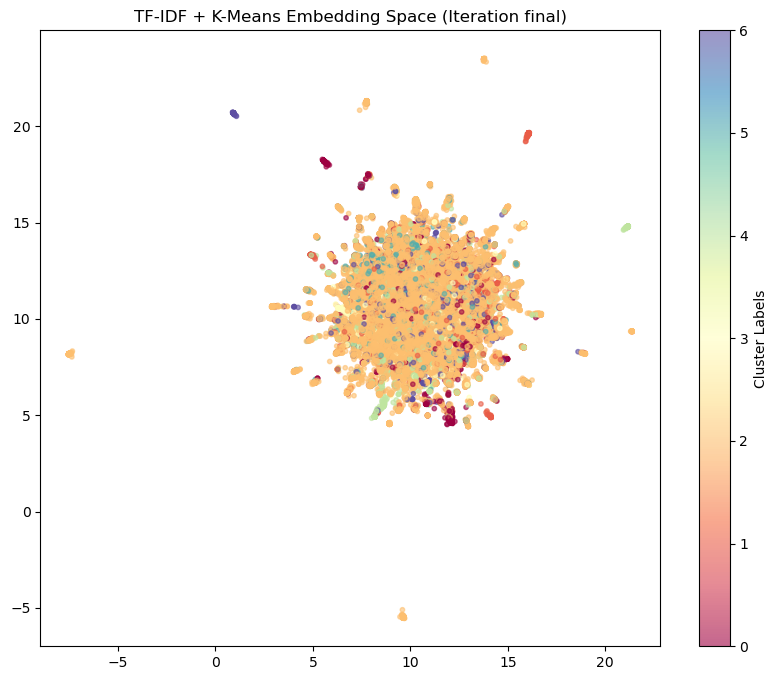

TF-IDF + K-Means scatter plot saved to embeddings_plots\tfidf_kmeans_scatter_iter_final.png
Visualization complete!


In [20]:
try:
    plot_tfidf_embeddings(tfidf_matrix, cluster_labels, plot_dir)
    print("Visualization complete!")
except Exception as e:
    print(f"Error generating visualization: {str(e)}")
    raise

## 21. Summary Statistics

In [21]:
print("\n=== CLUSTERING SUMMARY ===")
print(f"Total documents processed: {len(test_df)}")
print(f"Number of clusters: {len(np.unique(cluster_labels))}")
print(f"TF-IDF matrix dimensions: {tfidf_matrix.shape}")
print(f"Average confidence score: {np.mean(confidence_scores):.4f}")
if 'tfidf_sil_score' in locals():
    print(f"Silhouette Score: {tfidf_sil_score:.4f}")

# Cluster size distribution
cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print(f"\nCluster size distribution:")
for cluster_id, size in cluster_sizes.items():
    print(f"  Cluster {cluster_id}: {size} documents ({size/len(test_df)*100:.1f}%)")

print("\nAnalysis complete!")


=== CLUSTERING SUMMARY ===
Total documents processed: 70412
Number of clusters: 7
TF-IDF matrix dimensions: (70412, 5000)
Average confidence score: 0.1528
Silhouette Score: 0.0194

Cluster size distribution:
  Cluster 0: 2615 documents (3.7%)
  Cluster 1: 2306 documents (3.3%)
  Cluster 2: 56228 documents (79.9%)
  Cluster 3: 1337 documents (1.9%)
  Cluster 4: 2709 documents (3.8%)
  Cluster 5: 2383 documents (3.4%)
  Cluster 6: 2834 documents (4.0%)

Analysis complete!
